# EDA Playbook — Core 14-step workflow

Run top-to-bottom on any new dataset. Each cell does one check and prints a verdict that triggers an action.

For the full **finding → action** decision table, see `eda_decisions.md`. For pattern-by-pattern library lookup, use the toolkit cheatsheets.

Demo target: `data/crypto_hourly.parquet`. To re-use on your own data, swap the `df = pd.read_parquet(...)` line and the feature/target columns in the setup cell.

## Setup — run once

In [11]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_auc_score

pd.set_option('display.float_format', '{:.5f}'.format)

df = pd.read_parquet('../data/crypto_hourly.parquet')
df['ts'] = pd.to_datetime(df['ts'], utc=True)
df = df.sort_values(['symbol', 'ts']).reset_index(drop=True)

# Minimal feature panel for demonstration. Replace with your own features.
df['logret']         = df.groupby('symbol')['close'].transform(lambda c: np.log(c).diff())
df['logret_lag1']    = df.groupby('symbol')['logret'].shift(1)
df['logret_lag24']   = df.groupby('symbol')['logret'].shift(24)
df['vol_24h']        = df.groupby('symbol')['logret'].transform(lambda r: r.shift(1).rolling(24).std())
df['zscore_24h']     = (
    df.groupby('symbol')['logret'].transform(
        lambda r: (r - r.shift(1).rolling(24).mean()) / r.shift(1).rolling(24).std())
)
df['volume_z_24h']    = (
    df.groupby('symbol')['volume'].transform(
        lambda v: (v - v.shift(1).rolling(24).mean()) / v.shift(1).rolling(24).std())
) 
df['fwd_logret_24h'] = df.groupby('symbol')['logret'].transform(lambda r: r.rolling(24).sum().shift(-24))

FEATURES = ['logret_lag1', 'logret_lag24', 'vol_24h', 'zscore_24h', 'volume_z_24h']
TARGET   = 'fwd_logret_24h'
PANEL    = df.query('symbol == "BTC"').dropna(subset=FEATURES + [TARGET]).copy()

print(f'shape: {df.shape}  symbols: {df["symbol"].unique().tolist()}  span: {df["ts"].min().date()} → {df["ts"].max().date()}')
print(f'panel for analysis: BTC, n={len(PANEL):,}, features={FEATURES}, target={TARGET}')

shape: (70080, 14)  symbols: ['BNB', 'BTC', 'ETH', 'SOL']  span: 2024-04-19 → 2026-04-19
panel for analysis: BTC, n=17,471, features=['logret_lag1', 'logret_lag24', 'vol_24h', 'zscore_24h', 'volume_z_24h'], target=fwd_logret_24h


## Universal core (steps 1–5)

### 1. Missing-data audit

In [12]:
miss = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
print(miss.to_string())
verdict_missing = '>30% drop' if miss.max() > 30 else '5-30% impute' if miss.max() > 5 else '<5% drop rows or impute'
print(f'\n→ max {miss.max():.1f}% — action: {verdict_missing}')

vol_24h          0.14000
logret_lag24     0.14000
zscore_24h       0.14000
volume_z_24h     0.14000
fwd_logret_24h   0.14000
logret_lag1      0.01000
logret           0.01000
close            0.00000
volume           0.00000
high             0.00000
open             0.00000
ts               0.00000
low              0.00000
symbol           0.00000

→ max 0.1% — action: <5% drop rows or impute


### 2. Cardinality + dtype

In [13]:
print('Dtypes:')
print(df.dtypes.to_string())
print('\nCardinality (% unique):')
print((df.nunique() / len(df) * 100).round(2).to_string())
print('\n→ Drop near-IDs (>95% unique) | cast obvious numerics | low-card → category')

Dtypes:
ts                datetime64[ns, UTC]
open                          float64
high                          float64
low                           float64
close                         float64
volume                        float64
symbol                         object
logret                        float64
logret_lag1                   float64
logret_lag24                  float64
vol_24h                       float64
zscore_24h                    float64
volume_z_24h                  float64
fwd_logret_24h                float64

Cardinality (% unique):
ts               25.00000
open             78.74000
high             76.12000
low              76.60000
close            78.72000
volume           99.98000
symbol            0.01000
logret           99.20000
logret_lag1      99.19000
logret_lag24     99.06000
vol_24h          99.85000
zscore_24h       99.86000
volume_z_24h     99.86000
fwd_logret_24h   99.69000

→ Drop near-IDs (>95% unique) | cast obvious numerics | low-card → cat

### 3. Target distribution

mean: 0.00020  std: 0.02417
skew: -0.270  excess kurt: 3.086
JB p-value: 0.00000  →  NON-NORMAL

→ |skew|>0.5: log/Box-Cox  |  excess kurt > 3: MAE/Huber over MSE


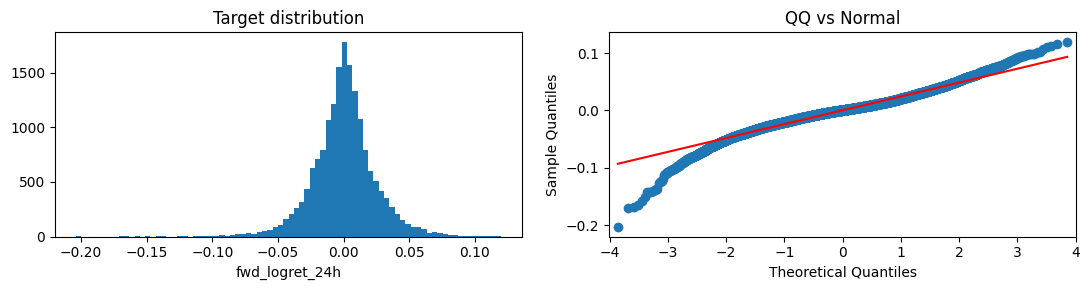

In [14]:
target = PANEL[TARGET]
skew_t = stats.skew(target)
kurt_t = stats.kurtosis(target)
jb_t   = stats.jarque_bera(target).pvalue

print(f'mean: {target.mean():.5f}  std: {target.std():.5f}')
print(f'skew: {skew_t:.3f}  excess kurt: {kurt_t:.3f}')
print(f'JB p-value: {jb_t:.5f}  →  {"NON-NORMAL" if jb_t < 0.05 else "NORMAL"}')
print(f'\n→ |skew|>0.5: log/Box-Cox  |  excess kurt > 3: MAE/Huber over MSE')

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(target, bins=80); ax[0].set_title('Target distribution'); ax[0].set_xlabel(TARGET)
sm.qqplot(target, line='s', ax=ax[1]); ax[1].set_title('QQ vs Normal')
plt.tight_layout(); plt.show()

### 4. Feature ↔ target correlation

In [15]:
corrs = PANEL[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
print('Pearson correlation with target:')
print(corrs.round(4).to_string())
print(f'\n→ Low |r| ≠ no signal — trees can find non-linear relationships. Best |r| here: {corrs.abs().max():.4f}')

Pearson correlation with target:
logret_lag1    -0.01610
zscore_24h     -0.00600
volume_z_24h    0.00210
logret_lag24    0.01010
vol_24h         0.05810

→ Low |r| ≠ no signal — trees can find non-linear relationships. Best |r| here: 0.0581


### 5. Multicollinearity (VIF)

In [16]:
X = PANEL[FEATURES]
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns)
print('VIF (>5 problematic, >10 severe):')
print(vif.round(2).to_string())
print('\nPearson correlation matrix:')
print(X.corr().round(3).to_string())
print(f'\n→ max VIF {vif.max():.2f} — action: {"DROP one or use ridge/lasso" if vif.max() > 5 else "OK"}')

VIF (>5 problematic, >10 severe):
logret_lag1    1.00000
logret_lag24   1.00000
vol_24h        1.00000
zscore_24h     1.00000
volume_z_24h   1.01000

Pearson correlation matrix:
              logret_lag1  logret_lag24  vol_24h  zscore_24h  volume_z_24h
logret_lag1       1.00000      -0.01200  0.00800    -0.03400      -0.05200
logret_lag24     -0.01200       1.00000 -0.03800    -0.03600      -0.00200
vol_24h           0.00800      -0.03800  1.00000     0.01200      -0.07700
zscore_24h       -0.03400      -0.03600  0.01200     1.00000      -0.04300
volume_z_24h     -0.05200      -0.00200 -0.07700    -0.04300       1.00000

→ max VIF 1.01 — action: OK


## Regression diagnostics (steps 6–8) — post-fit

6. Linearity: inspect plot below
7. Heteroscedasticity (Breusch-Pagan p): 0.00000  →  USE HC3 SEs (cov_type=HC3)
8. Residual normality (JB p):           0.00000  →  non-normal — bootstrap CIs


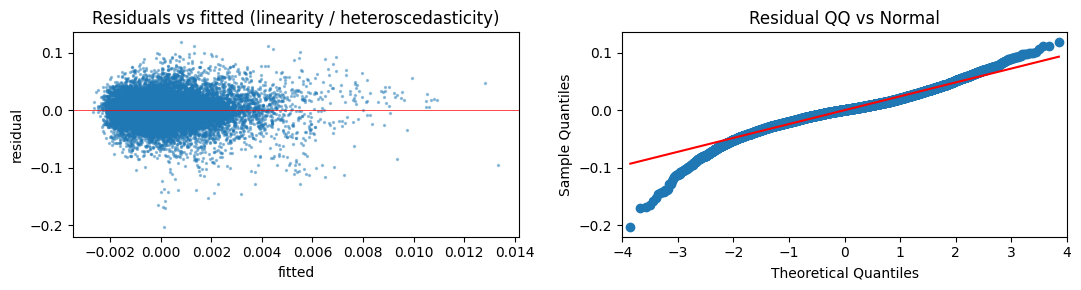

In [17]:
ols = smf.ols(f'{TARGET} ~ ' + ' + '.join(FEATURES), data=PANEL).fit()
resid = ols.resid

bp_p = het_breuschpagan(resid, sm.add_constant(X))[1]
jb_p = stats.jarque_bera(resid).pvalue

print(f'6. Linearity: inspect plot below')
print(f'7. Heteroscedasticity (Breusch-Pagan p): {bp_p:.5f}  →  {"USE HC3 SEs (cov_type=HC3)" if bp_p < 0.05 else "homoscedastic ✓"}')
print(f'8. Residual normality (JB p):           {jb_p:.5f}  →  {"non-normal — bootstrap CIs" if jb_p < 0.05 else "normal ✓"}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].scatter(ols.fittedvalues, resid, s=2, alpha=0.4); ax[0].axhline(0, color='red', lw=0.5)
ax[0].set_title('Residuals vs fitted (linearity / heteroscedasticity)')
ax[0].set_xlabel('fitted'); ax[0].set_ylabel('residual')
sm.qqplot(resid, line='s', ax=ax[1]); ax[1].set_title('Residual QQ vs Normal')
plt.tight_layout(); plt.show()

## Classification checks (steps 9–10)

In [18]:
panel_clf = PANEL.assign(direction=(PANEL[TARGET] > 0).astype(int))
balance = panel_clf['direction'].value_counts(normalize=True)

print('9. Class balance:')
print(balance.round(3).to_string())
print(f'   → {"IMBALANCED — use AUC, class_weight=balanced" if balance.min() < 0.3 else "balanced — accuracy is fine"}')
print()
print('10. Single-feature AUCs (separability):')
for f in FEATURES:
    auc = roc_auc_score(panel_clf['direction'], panel_clf[f])
    auc = max(auc, 1 - auc)
    print(f'    {f:20s} AUC = {auc:.3f}')
print('    → All <0.55: genuinely hard | best >0.7: easy problem')

9. Class balance:
direction
1   0.51300
0   0.48700
   → balanced — accuracy is fine

10. Single-feature AUCs (separability):
    logret_lag1          AUC = 0.506
    logret_lag24         AUC = 0.502
    vol_24h              AUC = 0.518
    zscore_24h           AUC = 0.513
    volume_z_24h         AUC = 0.502
    → All <0.55: genuinely hard | best >0.7: easy problem


## Time-series checks (steps 11–14)

### 11. Stationarity (ADF + KPSS verdict matrix)

In [19]:
y = PANEL['logret']
adf_p  = adfuller(y, regression='c')[1]
kpss_p = kpss(y, regression='c', nlags='auto')[1]

if adf_p < 0.05 and kpss_p > 0.05:
    verdict_stat = 'STATIONARY ✓'
elif adf_p > 0.05 and kpss_p < 0.05:
    verdict_stat = 'NON-STATIONARY — needs differencing'
elif adf_p < 0.05 and kpss_p < 0.05:
    verdict_stat = 'difference- or trend-stationary'
else:
    verdict_stat = 'inconclusive'

print(f'ADF p={adf_p:.4f}   (low → stationary)')
print(f'KPSS p={kpss_p:.4f}  (high → stationary)')
print(f'\n→ {verdict_stat}')

ADF p=0.0000   (low → stationary)
KPSS p=0.1000  (high → stationary)

→ STATIONARY ✓


### 12. Autocorrelation (ACF / PACF)

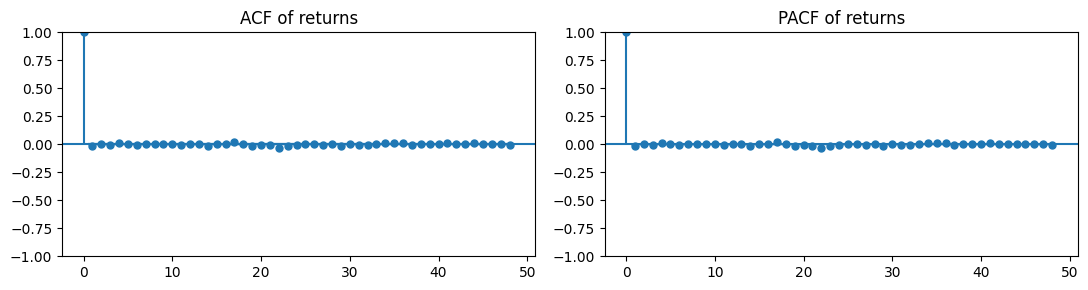

→ Significant lags suggest AR/MA terms; flat = white noise
→ PACF cuts at lag p → AR(p);  ACF cuts at lag q → MA(q)


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(y, lags=48, ax=ax[0])
ax[0].set_title('ACF of returns')
plot_pacf(y, lags=48, ax=ax[1])
ax[1].set_title('PACF of returns')
plt.tight_layout(); plt.show()
print('→ Significant lags suggest AR/MA terms; flat = white noise')
print('→ PACF cuts at lag p → AR(p);  ACF cuts at lag q → MA(q)')

### 13. Seasonality

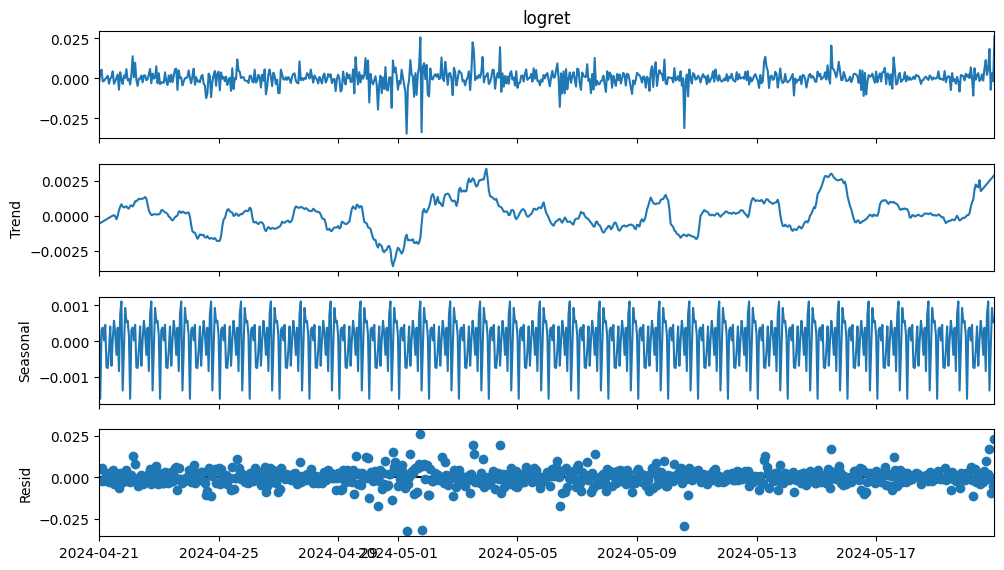

→ Strong seasonal component → Fourier features or SARIMA


In [11]:
y_idx = PANEL.set_index('ts')['logret']
y_short = y_idx.iloc[:30 * 24]   # first 30 days for speed
decomp = seasonal_decompose(y_short, period=24, model='additive', extrapolate_trend='freq')
fig = decomp.plot(); fig.set_size_inches(11, 6)
plt.show()
print('→ Strong seasonal component → Fourier features or SARIMA')

### 14. Volatility clustering

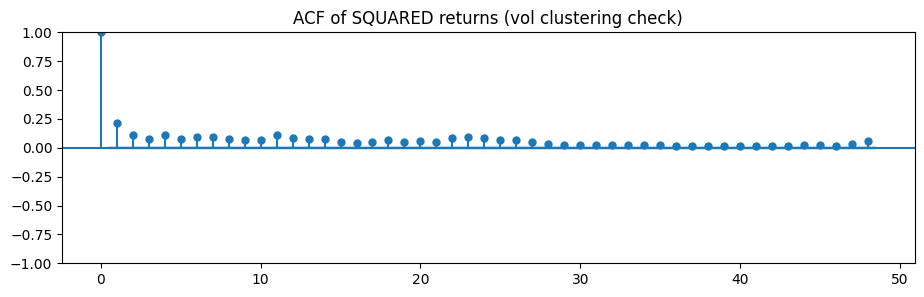

→ Persistent positive ACF on r² → vol clusters → GARCH or rolling-vol feature
  (raw returns can look uncorrelated while vol clusters strongly — check both)


In [12]:
fig, ax = plt.subplots(figsize=(11, 3))
plot_acf(y ** 2, lags=48, ax=ax)
ax.set_title('ACF of SQUARED returns (vol clustering check)')
plt.show()
print('→ Persistent positive ACF on r² → vol clusters → GARCH or rolling-vol feature')
print('  (raw returns can look uncorrelated while vol clusters strongly — check both)')

## Final verdict

In [13]:
print('=== EDA SUMMARY ===\n')
print('UNIVERSAL')
print(f'  Missing:           max {miss.max():.1f}% — {"OK" if miss.max() < 5 else "HANDLE"}')
print(f'  Multicollinearity: max VIF {vif.max():.2f} — {"OK" if vif.max() < 5 else "RIDGE/DROP"}')
print(f'  Target skew:       {skew_t:+.2f}   excess kurt: {kurt_t:+.2f}   JB p: {jb_t:.4f}')
print()
print('REGRESSION')
print(f'  Heteroscedastic:   {"YES — use HC3" if bp_p < 0.05 else "NO"}')
print(f'  Resid normal:      {"NO — bootstrap CIs" if jb_p < 0.05 else "YES"}')
print()
print('CLASSIFICATION')
print(f'  Class balance:     {balance.min():.2f} / {balance.max():.2f}')
print()
print('TIME-SERIES')
print(f'  Stationarity:      {verdict_stat}')
print(f'  Vol clustering:    inspect ACF of r² above (typically YES for crypto)')
print()
print('See eda_decisions.md for the full finding → action table.')

=== EDA SUMMARY ===

UNIVERSAL
  Missing:           max 0.1% — OK
  Multicollinearity: max VIF 1.00 — OK
  Target skew:       -0.27   excess kurt: +3.09   JB p: 0.0000

REGRESSION
  Heteroscedastic:   YES — use HC3
  Resid normal:      NO — bootstrap CIs

CLASSIFICATION
  Class balance:     0.49 / 0.51

TIME-SERIES
  Stationarity:      STATIONARY ✓
  Vol clustering:    inspect ACF of r² above (typically YES for crypto)

See eda_decisions.md for the full finding → action table.
